# 3. 模型样本外预测比较

本 notebook 按 Research_Design_Roadmap.md 比较五个模型：

1. Rolling Normal
2. Linear Quantile
3. Fused Normal K1
4. Fused Normal K3
5. Structured Normal K3

比较规则固定为：只保留五个模型共同拥有的股票—月份；先计算股票层评分，再在每个月内等权平均，最后让月份等权。模型优劣只依据样本外预测评分，不使用资产组合收益。

主要指标：

- 5% FZ0 joint VaR--ES score，越低越好；
- 0%--5% tail-CRPS，越低越好。
- 0%--10% tail-CRPS，越低越好。
- NLL
- CRPS
- 5% Quantile Score
- 10% Quantile Score
- VaR coverage
- PIT

次要指标包括 1% FZ0, 1% Quantile Score。Linear Quantile 没有天然密度，因此不计算精确 NLL；其 PIT 是由预测分位数插值得到的近似值。

**ES 口径**：$ES_\alpha=E[R\mid R\le VaR_\alpha]$，亏损保留负数。


In [1]:
# ==========================================
# 1. 导入库并设置路径、模型和评分参数
# ==========================================
from pathlib import Path
from datetime import datetime
import gc
import json
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.special import logsumexp
from scipy.stats import norm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)


# 选择要使用的预测时间戳(不使用的版本就注释掉)
# timestamp = "20260924_0227" # rank + training 72 months + ffi12 + random seed 2027
timestamp = "20260924_0457" # rank + training 72 months + ffi12 + random seed 42
timestamp = "20260924_0807" # rank + training 72 months + ffi12 + random seed 42 + new quantile levels
timestamp = "20260925_0018" # rank + training 72 months + ffi12 + random seed 42 + new quantile levels + flim

project_root = Path("/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN")
forecast_dir = Path("/Users/jianbinchen/Downloads/results")

result_dir = project_root / "output"
figure_dir = project_root / "overleaf/fig"

model_order = [
    "rolling_normal", 
    "linear_quantile", 
    "fused_normal_k1",
    "fused_normal_k3", 
    "structured_normal_k3",
    # "film_sigma",
    # "film_all"
]

model_labels = {
    "rolling_normal": "Rolling Normal",
    "linear_quantile": "Linear Quantile",
    "fused_normal_k1": "Fused Normal K1",
    "fused_normal_k3": "Fused Normal K3",
    "structured_normal_k3": "Structured Normal K3",
    # "film_sigma": "FiLM Sigma",
    # "film_all": "FiLM All"
}

model_files = {
    "rolling_normal": forecast_dir / f"rolling_normal_forecasts_{timestamp}.parquet",
    "linear_quantile": forecast_dir / f"linear_quantile_forecasts_{timestamp}.parquet",
    "fused_normal_k1": forecast_dir / f"fused_k1_forecasts_{timestamp}.parquet",
    "fused_normal_k3": forecast_dir / f"fused_k3_forecasts_{timestamp}.parquet",
    "structured_normal_k3": forecast_dir / f"structured_forecasts_{timestamp}.parquet",
    # "film_sigma": forecast_dir / f"film_sigma_forecasts_{timestamp}.parquet",
    # "film_all": forecast_dir / f"film_all_forecasts_{timestamp}.parquet"
}

model_steps = [
    ("linear_quantile", "rolling_normal", "条件信息"),
    ("fused_normal_k1", "linear_quantile", "非线性单分布"),
    ("fused_normal_k3", "fused_normal_k1", "Mixture"),
    ("structured_normal_k3", "fused_normal_k3", "结构化参数映射"),
    ("structured_normal_k3", "rolling_normal", "structured k3 vs rolling"),
    ("structured_normal_k3", "linear_quantile", "structured k3 vs linear"),
    ("structured_normal_k3", "fused_normal_k1", "structured k3 vs fused_k1"),
    # ("film_sigma", "structured_normal_k3", "film sigma vs structured k3"),
    # ("film_all", "structured_normal_k3", "film all vs structured k3"),
    # ("film_sigma", "film_all", "film sigma vs film all"),
]

# ==========================================
# read all files and display the first few rows
# ==========================================
for model, file in model_files.items():
    df = pd.read_parquet(file)
    print(f"Model: {model}")
    display(pd.concat([df.head(3), df.tail(3)]))



Model: rolling_normal


,permno,mthcaldt,target_ret_final,model_id,pred_mean,pred_vol,history_n,var_5,es_5,var_10,es_10
0,10001,2007-01-31,0.264774,rolling_normal,0.012281,0.111545,84,-0.171194,-0.217804,-0.130669,-0.183478
1,10025,2007-01-31,-0.028094,rolling_normal,0.019477,0.167332,84,-0.255759,-0.325681,-0.194967,-0.274188
2,10026,2007-01-31,-0.038517,rolling_normal,0.022379,0.096136,84,-0.135751,-0.175922,-0.100824,-0.146338
480443,93426,2024-12-31,-0.007243,rolling_normal,0.004015,0.098320,84,-0.157707,-0.198791,-0.121987,-0.168535
480444,93434,2024-12-31,0.147685,rolling_normal,1.099275,1.366048,2,-1.147674,-1.718490,-0.651386,-1.298117
480445,93436,2024-12-31,0.001882,rolling_normal,0.054494,0.204559,84,-0.281976,-0.367453,-0.207660,-0.304504


Model: linear_quantile


,permno,mthcaldt,target_ret_final,model_id,validation_loss,epochs_run,pred_mean,pred_vol,var_5,es_5,var_10,es_10,quantile_levels,quantile_vec
0,10001,2007-01-31,0.264774,linear_quantile,0.019430,51,-0.009233,0.135248,-0.195499,-0.296619,-0.135377,-0.227223,"[0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.0...","[-0.39249086380004883, -0.30906301736831665, -..."
1,10025,2007-01-31,-0.028094,linear_quantile,0.019430,51,-0.004797,0.157349,-0.210860,-0.300582,-0.167212,-0.242199,"[0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.0...","[-0.3876670300960541, -0.3131679892539978, -0...."
2,10026,2007-01-31,-0.038517,linear_quantile,0.019430,51,-0.012732,0.137731,-0.211667,-0.309595,-0.147989,-0.241165,"[0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.0...","[-0.3993987739086151, -0.3276469111442566, -0...."
480443,93426,2024-12-31,-0.007243,linear_quantile,0.024531,51,-0.003909,0.142705,-0.246571,-0.320871,-0.175855,-0.264430,"[0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.0...","[-0.39643192291259766, -0.3209168016910553, -0..."
480444,93434,2024-12-31,0.147685,linear_quantile,0.024531,51,-0.017982,0.201583,-0.336784,-0.418831,-0.263780,-0.357875,"[0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.0...","[-0.5016553401947021, -0.4198240041732788, -0...."
480445,93436,2024-12-31,0.001882,linear_quantile,0.024531,51,-0.008589,0.120876,-0.180859,-0.234063,-0.150703,-0.198952,"[0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.0...","[-0.2942931354045868, -0.23268258571624756, -0..."


Model: fused_normal_k1


,permno,mthcaldt,target_ret_final,window,model_id,pi_vec,pi_logits_vec,mu_vec,sigma_vec,nu_vec,var_5,es_5,var_10,es_10
0,10001,2007-01-31,0.264774,0,fused_normal_k1,[1.0],[0.0],[0.013480894267559052],[0.11423509567975998],None,-0.174419,-0.222153,-0.132917,-0.187000
1,10025,2007-01-31,-0.028094,0,fused_normal_k1,[1.0],[0.0],[-0.0070756529457867146],[0.13849738240242004],None,-0.234884,-0.292756,-0.184567,-0.250136
2,10026,2007-01-31,-0.038517,0,fused_normal_k1,[1.0],[0.0],[-0.003198858816176653],[0.09585005789995193],None,-0.160858,-0.200910,-0.126036,-0.171414
480443,93426,2024-12-31,-0.007243,17,fused_normal_k1,[1.0],[0.0],[0.01433954294770956],[0.12232233583927155],None,-0.186863,-0.237976,-0.142423,-0.200334
480444,93434,2024-12-31,0.147685,17,fused_normal_k1,[1.0],[0.0],[0.003010000102221966],[0.29875263571739197],None,-0.488394,-0.613231,-0.379857,-0.521296
480445,93436,2024-12-31,0.001882,17,fused_normal_k1,[1.0],[0.0],[-0.02080928161740303],[0.15022359788417816],None,-0.267905,-0.330677,-0.213329,-0.284449


Model: fused_normal_k3


,permno,mthcaldt,target_ret_final,window,model_id,pi_vec,pi_logits_vec,mu_vec,sigma_vec,nu_vec,var_5,es_5,var_10,es_10
0,10001,2007-01-31,0.264774,0,fused_normal_k3,"[0.27000343799591064, 0.522145688533783, 0.207...","[-0.12497229874134064, 0.5345395803451538, -0....","[-0.013287877663969994, 0.011403180658817291, ...","[0.08551321923732758, 0.07616066932678223, 0.2...",None,-0.163910,-0.253428,-0.117128,-0.195430
1,10025,2007-01-31,-0.028094,0,fused_normal_k3,"[0.3765127658843994, 0.4287175238132477, 0.194...","[0.18730294704437256, 0.31714925169944763, -0....","[-0.06455773115158081, 0.007287534885108471, 0...","[0.10382706671953201, 0.09341229498386383, 0.3...",None,-0.243524,-0.366395,-0.182553,-0.287730
2,10026,2007-01-31,-0.038517,0,fused_normal_k3,"[0.2399177849292755, 0.5415216684341431, 0.218...","[-0.23771613836288452, 0.5763707160949707, -0....","[-0.006034683436155319, 0.0010895095765590668,...","[0.07406836748123169, 0.06495867669582367, 0.1...",None,-0.140873,-0.206408,-0.103022,-0.162993
480443,93426,2024-12-31,-0.007243,17,fused_normal_k3,"[0.01244056224822998, 0.3441367745399475, 0.64...","[-2.3884174823760986, 0.931659460067749, 1.557...","[0.11964355409145355, 0.0046445876359939575, -...","[0.3511994183063507, 0.1341320425271988, 0.072...",None,-0.164173,-0.226487,-0.124318,-0.184233
480444,93434,2024-12-31,0.147685,17,fused_normal_k3,"[0.02369285561144352, 0.5727038979530334, 0.40...","[-1.8648338317871094, 1.3203613758087158, 0.97...","[0.28800928592681885, -0.040308862924575806, -...","[0.7333284616470337, 0.22083774209022522, 0.11...",None,-0.355562,-0.480284,-0.272425,-0.394843
480445,93436,2024-12-31,0.001882,17,fused_normal_k3,"[0.02096131443977356, 0.46318966150283813, 0.5...","[-2.0416789054870605, 1.0537790060043335, 1.16...","[0.12103810906410217, -0.03292977064847946, -0...","[0.359854519367218, 0.14445491135120392, 0.087...",None,-0.230052,-0.300297,-0.180451,-0.251451


Model: structured_normal_k3


,permno,mthcaldt,target_ret_final,window,adverse_component,normal_component,favorable_component,model_id,pi_vec,pi_logits_vec,mu_vec,sigma_vec,nu_vec,var_5,es_5,var_10,es_10
0,10001,2007-01-31,0.264774,0,1,2,0,structured_normal_k3,"[0.113340824842453, 0.5285136699676514, 0.3581...","[-0.9614662528038025, 0.5782029628753662, 0.18...","[0.1298636496067047, 0.002417616546154022, -0....","[0.18544413149356842, 0.08298581838607788, 0.0...",None,-0.126501,-0.169206,-0.096327,-0.139562
1,10025,2007-01-31,-0.028094,0,1,2,0,structured_normal_k3,"[0.113340824842453, 0.5285136699676514, 0.3581...","[-0.9614662528038025, 0.5782029628753662, 0.18...","[0.15086984634399414, -0.0834188163280487, 0.0...","[0.20183180272579193, 0.13692262768745422, 0.1...",None,-0.269773,-0.332184,-0.214963,-0.286083
2,10026,2007-01-31,-0.038517,0,1,2,0,structured_normal_k3,"[0.113340824842453, 0.5285136699676514, 0.3581...","[-0.9614662528038025, 0.5782029628753662, 0.18...","[0.09510147571563721, -0.034472014755010605, 0...","[0.11469686776399612, 0.07487363368272781, 0.0...",None,-0.136563,-0.170743,-0.107137,-0.145628
480443,93426,2024-12-31,-0.007243,17,0,1,2,structured_normal_k3,"[0.254055380821228, 0.6860688924789429, 0.0598...","[0.08684087544679642, 1.0802665948867798, -1.3...","[-0.09150286018848419, 0.03706655651330948, 0....","[0.07828476279973984, 0.07130841165781021, 0.2...",None,-0.167370,-0.216650,-0.126004,-0.180820
480444,93434,2024-12-31,0.147685,17,0,1,2,structured_normal_k3,"[0.254055380821228, 0.6860688924789429, 0.0598...","[0.08684087544679642, 1.0802665948867798, -1.3...","[-0.18249942362308502, 0.020507389679551125, 0...","[0.1596684455871582, 0.1779317855834961, 0.458...",None,-0.365104,-0.463546,-0.291298,-0.394223
480445,93436,2024-12-31,0.001882,17,0,1,2,structured_normal_k3,"[0.254055380821228, 0.6860688924789429, 0.0598...","[0.08684087544679642, 1.0802665948867798, -1.3...","[-0.11416181176900864, 0.044104091823101044, 0...","[0.08528715372085571, 0.08420176804065704, 0.2...",None,-0.198129,-0.255970,-0.151934,-0.214576


In [2]:
alphas = (0.05, 0.10)
alpha_suffix = {0.01: "1", 0.05: "5", 0.10: "10"}
# quantile_levels = np.array([
#     0.001, 0.0025, 0.005, 0.01, 0.025, 0.05, 0.10, 0.25, 0.50,
#     0.75, 0.90, 0.95, 0.975, 0.99, 0.995, 0.9975, 0.999,
# ])
quantile_levels = np.array([
    0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 
    0.15, 0.25, 0.40, 0.50, 0.60, 0.75, 0.85, 
    0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99
], dtype=float)
tail_alpha = [0.05, 0.10]
score_chunk_size = 20_000
bisection_iterations = 40
newey_west_lags = 12
save_row_scores = False  # True 会额外保存五个较大的股票层评分文件

In [3]:
# ==========================================
# 2. 建立五个模型的共同股票—月份样本
# ==========================================
# 主要为了生成commen_index
key_cols = ["permno", "mthcaldt"]
tail_cols = [f"{name}_{alpha_suffix[alpha]}" for alpha in alphas for name in ("var", "es")]

coverage_rows, target_series = [], {}
common_index = None

for model_id in model_order:
    path = model_files[model_id]
    core = pd.read_parquet(path, columns=key_cols + ["target_ret_final"])
    core["mthcaldt"] = pd.to_datetime(core["mthcaldt"])
    if core.duplicated(key_cols).any():
        raise ValueError(f"{model_id} 存在重复股票—月份。")

    indexed_target = core.set_index(key_cols)["target_ret_final"].sort_index()
    target_series[model_id] = indexed_target
    common_index = indexed_target.index if common_index is None else common_index.intersection(indexed_target.index, sort=False)
    coverage_rows.append({
        "model_id": model_id, "available_rows": len(core), "months": core["mthcaldt"].nunique(),
        "first_month": core["mthcaldt"].min(), "last_month": core["mthcaldt"].max(),
    })

common_index = common_index.sort_values()
if len(common_index) == 0:
    raise ValueError("五个模型没有共同股票—月份。")

reference_target = target_series[model_order[0]].reindex(common_index).to_numpy()
for model_id in model_order[1:]:
    difference = np.nanmax(np.abs(target_series[model_id].reindex(common_index).to_numpy() - reference_target))
    if difference > 1e-10:
        raise ValueError(f"{model_id} 与 Rolling Normal 的 realized return 不一致，最大差异为 {difference:g}。")

coverage_table = pd.DataFrame(coverage_rows).set_index("model_id").reindex(model_order)
coverage_table["common_rows"] = len(common_index)
coverage_table["common_share"] = coverage_table["common_rows"] / coverage_table["available_rows"]
del target_series, core
gc.collect()

print(f"共同样本：{len(common_index):,} 个股票—月份，共 {common_index.get_level_values('mthcaldt').nunique()} 个月")

coverage_table = coverage_table.reset_index()
coverage_table.to_parquet(result_dir / f"coverage_table_{timestamp}.parquet", index=False)
display(coverage_table)


共同样本：480,446 个股票—月份，共 216 个月


,model_id,available_rows,months,first_month,last_month,common_rows,common_share
0,rolling_normal,480446,216,2007-01-31,2024-12-31,480446,1.0
1,linear_quantile,480446,216,2007-01-31,2024-12-31,480446,1.0
2,fused_normal_k1,480446,216,2007-01-31,2024-12-31,480446,1.0
3,fused_normal_k3,480446,216,2007-01-31,2024-12-31,480446,1.0
4,structured_normal_k3,480446,216,2007-01-31,2024-12-31,480446,1.0


In [4]:
# ==========================================
# 3. 确定 FZ0 的共同有效样本
# ==========================================
# FZ0 要求 q < 0、e < 0 且 e <= q，其中 e 就是保存的收益率 ES。
fz_common_masks = {alpha: np.ones(len(common_index), dtype=bool) for alpha in alphas}
fz_domain_rows = []

for model_id in model_order:
    tail_path = model_files[model_id]
    tail = pd.read_parquet(tail_path, columns=key_cols + tail_cols)

    tail["mthcaldt"] = pd.to_datetime(tail["mthcaldt"])
    tail = tail.set_index(key_cols).reindex(common_index)

    for alpha in alphas:
        suffix = alpha_suffix[alpha]
        q = tail[f"var_{suffix}"].to_numpy(dtype=float)
        e = tail[f"es_{suffix}"].to_numpy(dtype=float)
        valid = np.isfinite(q) & np.isfinite(e) & (q < 0.0) & (e < 0.0) & (e <= q)
        fz_common_masks[alpha] &= valid
        fz_domain_rows.append({"model_id": model_id, "alpha": alpha, "model_valid_share": valid.mean()})

fz_domain_table = pd.DataFrame(fz_domain_rows)
common_shares = {alpha: mask.mean() for alpha, mask in fz_common_masks.items()}
fz_domain_table["all_model_common_share"] = fz_domain_table["alpha"].map(common_shares)
del tail
gc.collect()

fz_domain_table.to_parquet(result_dir / f"fz_domain_table_{timestamp}.parquet", index=False)

display(fz_domain_table.pivot(index="model_id", columns="alpha", values="model_valid_share").reindex(model_order).round(6))
print("FZ0 五模型共同有效样本比例：", {f"{alpha:.0%}": f"{share:.2%}" for alpha, share in common_shares.items()})
display(fz_domain_table)


alpha,0.05,0.10
model_id,,
rolling_normal,0.997396,0.996330
linear_quantile,0.991104,0.978897
fused_normal_k1,0.999998,0.998655
fused_normal_k3,0.999286,0.991785
structured_normal_k3,1.000000,1.000000


FZ0 五模型共同有效样本比例： {'5%': '98.78%', '10%': '96.72%'}


,model_id,alpha,model_valid_share,all_model_common_share
0,rolling_normal,0.05,0.997396,0.987803
1,rolling_normal,0.10,0.996330,0.967185
2,linear_quantile,0.05,0.991104,0.987803
3,linear_quantile,0.10,0.978897,0.967185
4,fused_normal_k1,0.05,0.999998,0.987803
5,fused_normal_k1,0.10,0.998655,0.967185
6,fused_normal_k3,0.05,0.999286,0.987803
7,fused_normal_k3,0.10,0.991785,0.967185
8,structured_normal_k3,0.05,1.000000,0.987803
9,structured_normal_k3,0.10,1.000000,0.967185


## 评分方法

CRPS 与 tail-CRPS 都用五个模型共享的 17 个分位数网格进行梯形积分。网格两端使用最外侧分位数作常数延伸，因此所有模型采用完全相同的离散近似。

FZ0 使用 return-space ES：

$$
e_{i,t,\alpha}=ES_{i,t,\alpha}=E[R_{i,t+1}\mid R_{i,t+1}\le q_{i,t,\alpha}].
$$

评分公式为：

$$
L_{FZ0}(y,q,e;\alpha)
=
-\frac{\mathbf 1(y\le q)(q-y)}{\alpha e}
+\frac{q}{e}+\log(-e)-1.
$$

为了不让不同模型使用不同观测，FZ0 仅在五个模型共同满足定义域的股票—月份上计算。保留比例由上表报告。

公式中的 `log(-e)` 是 FZ0 在 `e < 0` 定义域上的对数项，保留不变；它不改变 ES 的保存口径。分解中的 contribution 和 severity 同样采用收益率口径，tail weight 仍为非负概率权重。


In [5]:
# ==========================================
# 4. 通用评分函数
# ==========================================
def decode_matrix(series):
    """将 parquet 中的 JSON/list 向量列转成二维 NumPy array。"""
    return np.stack([json.loads(x) if isinstance(x, str) else x for x in series]).astype(float, copy=False)


def pinball_loss(y, levels, quantiles):
    error = y[:, None] - quantiles
    return np.where(error >= 0.0, levels[None, :] * error, (levels[None, :] - 1.0) * error)


def score_quantile_grid(y, quantiles):
    """用共同分位数网格计算 CRPS、10% tail-CRPS 和 1%/5%/10% Quantile Score。"""
    quantiles = np.sort(np.asarray(quantiles, dtype=float), axis=1)
    full_levels = np.r_[0.0, quantile_levels, 1.0]
    full_quantiles = np.column_stack([quantiles[:, 0], quantiles, quantiles[:, -1]])
    crps = 2.0 * trapezoid(pinball_loss(y, full_levels, full_quantiles), full_levels, axis=1)
    scores = {"crps": crps}

    for alpha in tail_alpha:
        tail_mask = quantile_levels <= alpha
        tail_levels = np.r_[0.0, quantile_levels[tail_mask]]
        tail_quantiles = np.column_stack([
            quantiles[:, 0], quantiles[:, tail_mask]
        ])
        tail_crps = 2.0 * trapezoid(pinball_loss(y, tail_levels, tail_quantiles),tail_levels, axis=1,) / alpha
        scores[f"tail_crps_{alpha_suffix[alpha]}"] = tail_crps

    for alpha in alphas:
        position = np.flatnonzero(np.isclose(quantile_levels, alpha))[0]
        qs = 2.0 * pinball_loss(y, np.array([alpha]), quantiles[:, [position]])[:, 0]
        scores[f"qs_{alpha_suffix[alpha]}"] = qs
    return scores


def pit_from_quantiles(y, quantiles):
    """由单调分位数函数反推 Linear Quantile 的近似 PIT。"""
    quantiles = np.sort(np.asarray(quantiles, dtype=float), axis=1)
    count = (quantiles <= y[:, None]).sum(axis=1)
    pit = np.empty(len(y), dtype=float)
    below, above = count == 0, count == len(quantile_levels)
    pit[below], pit[above] = 0.0, 1.0

    middle_rows = np.flatnonzero(~(below | above))
    left = count[middle_rows] - 1
    right = left + 1
    q_left, q_right = quantiles[middle_rows, left], quantiles[middle_rows, right]
    fraction = np.divide(
        y[middle_rows] - q_left, q_right - q_left,
        out=np.full(len(middle_rows), 0.5), where=(q_right - q_left) > 1e-12,
    )
    pit[middle_rows] = quantile_levels[left] + fraction * (quantile_levels[right] - quantile_levels[left])
    return np.clip(pit, 0.0, 1.0)


def mixture_cdf(x, pi, mu, sigma):
    z = (x[..., None] - mu[:, None, :]) / sigma[:, None, :]
    return np.sum(pi[:, None, :] * norm.cdf(z), axis=2)


def mixture_quantiles(levels, pi, mu, sigma):
    """向量化二分法计算 Normal mixture quantiles。"""
    bracket_level = max(float(np.min(levels)) * 0.1, 1e-10)
    lower_component = mu + sigma * norm.ppf(bracket_level)
    upper_component = mu + sigma * norm.ppf(1.0 - bracket_level)
    lower = np.repeat(lower_component.min(axis=1)[:, None], len(levels), axis=1)
    upper = np.repeat(upper_component.max(axis=1)[:, None], len(levels), axis=1)

    for _ in range(bisection_iterations):
        middle = 0.5 * (lower + upper)
        cdf = mixture_cdf(middle, pi, mu, sigma)
        lower = np.where(cdf < levels[None, :], middle, lower)
        upper = np.where(cdf >= levels[None, :], middle, upper)
    return 0.5 * (lower + upper)


def fz0_score(y, q, es_return, alpha, common_valid):
    e = np.asarray(es_return, dtype=float)
    score = np.full(len(y), np.nan)
    hit = (y <= q).astype(float)
    score[common_valid] = (
        -hit[common_valid] * (q[common_valid] - y[common_valid]) / (alpha * e[common_valid])
        + q[common_valid] / e[common_valid] + np.log(-e[common_valid]) - 1.0
    )
    return score


def uniform_ks_distance(values):
    values = np.sort(np.asarray(values, dtype=float))
    n = len(values)
    return max((np.arange(1, n + 1) / n - values).max(), (values - np.arange(n) / n).max())


In [6]:
# ==========================================
# 5. 读取单个模型，并计算股票层评分
# ==========================================
def load_model(model_id):
    files = model_files[model_id]
    if model_id == "rolling_normal":
        columns = key_cols + ["target_ret_final", "model_id", "pred_mean", "pred_vol"] + tail_cols
    elif model_id == "linear_quantile":
        columns = key_cols + ["target_ret_final", "model_id", "quantile_levels", "quantile_vec"] + tail_cols
    else:
        columns = key_cols + ["target_ret_final", "model_id", "pi_vec", "mu_vec", "sigma_vec"] + tail_cols

    frame = pd.read_parquet(files, columns=columns)
    frame["mthcaldt"] = pd.to_datetime(frame["mthcaldt"])

    return frame.set_index(key_cols).reindex(common_index).reset_index()


def score_model(model_id):
    frame = load_model(model_id)
    y = frame["target_ret_final"].to_numpy(dtype=float)
    n = len(frame)
    nll = np.full(n, np.nan)
    pit = np.full(n, np.nan)

    if model_id == "rolling_normal":
        loc = frame["pred_mean"].to_numpy(dtype=float)
        scale = np.maximum(frame["pred_vol"].to_numpy(dtype=float), 1e-8)
        quantiles = loc[:, None] + scale[:, None] * norm.ppf(quantile_levels)[None, :]
        nll = -norm.logpdf(y, loc=loc, scale=scale)
        pit = norm.cdf(y, loc=loc, scale=scale)

    elif model_id == "linear_quantile":
        stored_levels = frame["quantile_levels"].iloc[0]
        stored_levels = np.asarray(json.loads(stored_levels) if isinstance(stored_levels, str) else stored_levels, dtype=float)
        if not np.allclose(stored_levels, quantile_levels):
            raise ValueError("Linear Quantile 的 quantile_levels 与比较网格不一致。")
        quantiles = np.sort(decode_matrix(frame["quantile_vec"]), axis=1)
        pit = pit_from_quantiles(y, quantiles)

    else:
        pi = decode_matrix(frame["pi_vec"])
        mu = decode_matrix(frame["mu_vec"])
        sigma = decode_matrix(frame["sigma_vec"])
        if np.any(sigma <= 0.0) or not np.allclose(pi.sum(axis=1), 1.0, atol=1e-5):
            raise ValueError(f"{model_id} 的 pi 或 sigma 无效。")

        quantiles = np.empty((n, len(quantile_levels)), dtype=float)
        for start in range(0, n, score_chunk_size):
            stop = min(start + score_chunk_size, n)
            sl = slice(start, stop)
            log_density = np.log(np.clip(pi[sl], 1e-12, 1.0)) + norm.logpdf(y[sl, None], loc=mu[sl], scale=sigma[sl])
            nll[sl] = -logsumexp(log_density, axis=1)
            pit[sl] = np.sum(pi[sl] * norm.cdf(y[sl, None], loc=mu[sl], scale=sigma[sl]), axis=1)
            quantiles[sl] = mixture_quantiles(quantile_levels, pi[sl], mu[sl], sigma[sl])

    # 1%、5%、10% 分位数使用预测文件中已经保存的 VaR，并检查与本次分位数计算一致。
    quantile_differences = {}
    for alpha in alphas:
        suffix = alpha_suffix[alpha]
        position = np.flatnonzero(np.isclose(quantile_levels, alpha))[0]
        stored_var = frame[f"var_{suffix}"].to_numpy(dtype=float)
        quantile_differences[f"var_{suffix}_max_abs_diff"] = np.max(np.abs(quantiles[:, position] - stored_var))
        quantiles[:, position] = stored_var

    grid_scores = score_quantile_grid(y, quantiles)
    output = frame[key_cols].copy()
    output["target_ret_final"] = y
    output["model_id"] = model_id
    output["nll"] = nll
    output["pit"] = np.clip(pit, 0.0, 1.0)
    for name, values in grid_scores.items():
        output[name] = values

    for alpha in alphas:
        suffix = alpha_suffix[alpha]
        q = frame[f"var_{suffix}"].to_numpy(dtype=float)
        es_return = frame[f"es_{suffix}"].to_numpy(dtype=float)
        output[f"coverage_{suffix}"] = (y <= q).astype(float)
        output[f"fz0_{suffix}"] = fz0_score(y, q, es_return, alpha, fz_common_masks[alpha])

    return output, {"model_id": model_id, **quantile_differences}


In [7]:
# ==========================================
# 6. 逐个模型评分，并立即聚合到月度层
# ==========================================
# 基础静态列
loss_columns = ["nll", "crps"]
# 动态扩展各个指标基于 alpha 的列
loss_columns += [f"tail_crps_{alpha_suffix[a]}" for a in alphas]
loss_columns += [f"qs_{alpha_suffix[a]}" for a in alphas]
loss_columns += [f"fz0_{alpha_suffix[a]}" for a in alphas]

coverage_columns = [f"coverage_{alpha_suffix[a]}" for a in alphas]
fz0_columns = [f"fz0_{alpha_suffix[a]}" for a in alphas]
monthly_parts, pit_parts, pit_hist_parts, quantile_checks = [], [], [], []

# model_order=["structured_normal_k3"]


for model_id in model_order:
    print(f"Scoring {model_labels[model_id]} ...")
    row_scores, check = score_model(model_id)
    quantile_checks.append(check)

    monthly = row_scores.groupby("mthcaldt", as_index=False).agg(
        n_firms=("permno", "size"),
        **{column: (column, "mean") for column in loss_columns + coverage_columns},
        **{f"n_{column}": (column, "count") for column in fz0_columns},
    )
    monthly["model_id"] = model_id
    monthly_parts.append(monthly)

    for month, group in row_scores.groupby("mthcaldt", sort=True):
        values = group["pit"].to_numpy(dtype=float)
        pit_parts.append({
            "model_id": model_id, "mthcaldt": month, "pit_mean": values.mean(),
            "pit_variance": values.var(ddof=0), "pit_ks": uniform_ks_distance(values),
        })

    pit_bin = np.minimum((row_scores["pit"].to_numpy() * 10).astype(int), 9)
    month_bins = pd.crosstab(row_scores["mthcaldt"], pit_bin).reindex(columns=range(10), fill_value=0)
    month_bins = month_bins.div(month_bins.sum(axis=1), axis=0)
    pit_hist_parts.append(pd.DataFrame({
        "model_id": model_id, "pit_bin": np.arange(10), "frequency": month_bins.mean(axis=0).to_numpy(),
    }))

    if save_row_scores:
        row_scores.to_parquet(result_dir / f"row_scores_{model_id}_{timestamp}.parquet", index=False)

    del row_scores, monthly, month_bins
    gc.collect()

monthly_scores = pd.concat(monthly_parts, ignore_index=True)
monthly_pit = pd.DataFrame(pit_parts)
pit_histogram = pd.concat(pit_hist_parts, ignore_index=True)
quantile_check_table = pd.DataFrame(quantile_checks).set_index("model_id").reindex(model_order)

print("全部模型评分完成。")
display(monthly_scores)
display(monthly_pit)
display(pit_histogram)
display(quantile_check_table)
monthly_scores.to_parquet(result_dir / f"monthly_scores_{timestamp}.parquet", index=False)
monthly_pit.to_parquet(result_dir / f"monthly_pit_{timestamp}.parquet", index=False)
pit_histogram.to_parquet(result_dir / f"pit_histogram_{timestamp}.parquet", index=False)
quantile_check_table.reset_index().to_parquet(result_dir / f"quantile_check_table_{timestamp}.parquet", index=False)

Scoring Rolling Normal ...
Scoring Linear Quantile ...
Scoring Fused Normal K1 ...
Scoring Fused Normal K3 ...
Scoring Structured Normal K3 ...
全部模型评分完成。


,mthcaldt,n_firms,nll,crps,tail_crps_5,tail_crps_10,qs_5,qs_10,fz0_5,fz0_10,coverage_5,coverage_10,n_fz0_5,n_fz0_10,model_id
0,2007-01-31,2870,7.968089,0.058685,0.014884,0.023732,0.025175,0.039064,-1.434564,-1.748891,0.026481,0.051568,2858,2853,rolling_normal
1,2007-02-28,2871,-0.755286,0.056448,0.014809,0.024095,0.025542,0.040246,-1.450308,-1.719124,0.025427,0.046674,2864,2860,rolling_normal
2,2007-03-31,2854,-0.739022,0.056720,0.014876,0.024432,0.025918,0.041095,-1.590968,-1.829191,0.016468,0.029783,2846,2842,rolling_normal
3,2007-04-30,2864,0.790061,0.063404,0.014976,0.024903,0.026389,0.042381,-1.529800,-1.809144,0.017458,0.033869,2857,2855,rolling_normal
4,2007-05-31,2863,-0.653724,0.057399,0.014154,0.022562,0.024038,0.036995,-1.334241,-1.653887,0.038421,0.065316,2853,2849,rolling_normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,2024-08-31,2059,-0.800401,0.065814,0.014911,0.025199,0.026422,0.043845,-1.481191,-1.669047,0.013113,0.028655,2054,2048,structured_normal_k3
1076,2024-09-30,2052,-0.768035,0.067842,0.014426,0.024195,0.025355,0.041880,-1.392010,-1.575147,0.035088,0.066764,2048,2045,structured_normal_k3
1077,2024-10-31,2076,-0.198448,0.105899,0.019480,0.033234,0.034563,0.058524,-1.458717,-1.686460,0.027457,0.041908,2070,2068,structured_normal_k3
1078,2024-11-30,2088,-0.693939,0.072091,0.014569,0.023785,0.024824,0.040575,-1.213364,-1.348491,0.079502,0.160441,2079,2075,structured_normal_k3


,model_id,mthcaldt,pit_mean,pit_variance,pit_ks
0,rolling_normal,2007-01-31,0.445982,0.049110,0.176221
1,rolling_normal,2007-02-28,0.475499,0.048912,0.143390
2,rolling_normal,2007-03-31,0.521640,0.050903,0.137839
3,rolling_normal,2007-04-30,0.536022,0.059872,0.120154
4,rolling_normal,2007-05-31,0.418107,0.050020,0.201955
...,...,...,...,...,...
1075,structured_normal_k3,2024-08-31,0.602334,0.053063,0.212313
1076,structured_normal_k3,2024-09-30,0.506133,0.069869,0.056352
1077,structured_normal_k3,2024-10-31,0.696015,0.079284,0.293765
1078,structured_normal_k3,2024-11-30,0.367653,0.064895,0.226459


,model_id,pit_bin,frequency
0,rolling_normal,0,0.101303
1,rolling_normal,1,0.095329
2,rolling_normal,2,0.109044
3,rolling_normal,3,0.119413
4,rolling_normal,4,0.123025
5,rolling_normal,5,0.109880
6,rolling_normal,6,0.095668
7,rolling_normal,7,0.084248
8,rolling_normal,8,0.072396
9,rolling_normal,9,0.089694


,var_5_max_abs_diff,var_10_max_abs_diff
model_id,,
rolling_normal,0.000000e+00,0.000000e+00
linear_quantile,0.000000e+00,0.000000e+00
fused_normal_k1,1.045830e-12,2.835510e-13
fused_normal_k3,2.467970e-12,2.698508e-12
structured_normal_k3,1.844191e-12,1.966982e-12


In [8]:
summary_columns = loss_columns + coverage_columns
comparison_summary = monthly_scores.groupby("model_id")[summary_columns].mean()
for alpha in alphas:
    suffix = alpha_suffix[alpha]
    comparison_summary[f"coverage_error_{suffix}"] = (comparison_summary[f"coverage_{suffix}"] - alpha).abs()

# calculate ranks for all metrics
for column in comparison_summary.columns:
    rank_column = f"rank_{column}"
    comparison_summary[rank_column] = comparison_summary[column].rank(method="min", ascending=True)
comparison_summary = comparison_summary.reindex(model_order).reset_index()
comparison_summary.to_parquet(result_dir / f"comparison_summary_{timestamp}.parquet", index=False)
comparison_summary
# 没有提取每个月股票的数量, 如果需要, 以后再提取吧
# for alpha in alphas:
#     suffix = alpha_suffix[alpha]
#     comparison_summary[f"fz0_months_{suffix}"] = monthly_scores.groupby("model_id")[f"fz0_{suffix}"].count().reindex(model_order)


,model_id,nll,crps,tail_crps_5,tail_crps_10,qs_5,qs_10,fz0_5,fz0_10,coverage_5,coverage_10,coverage_error_5,coverage_error_10,rank_nll,rank_crps,rank_tail_crps_5,rank_tail_crps_10,rank_qs_5,rank_qs_10,rank_fz0_5,rank_fz0_10,rank_coverage_5,rank_coverage_10,rank_coverage_error_5,rank_coverage_error_10
0,rolling_normal,61486.848591,0.075154,0.019054,0.029743,0.031244,0.048734,-1.210867,-1.482878,0.058581,0.101303,0.008581,0.001303,4.0,2.0,5.0,3.0,3.0,2.0,2.0,1.0,3.0,3.0,3.0,2.0
1,linear_quantile,NaN,0.084006,0.017486,0.031088,0.032668,0.056078,-1.180098,-1.410592,0.057230,0.099905,0.007230,0.000095,NaN,5.0,3.0,5.0,5.0,5.0,4.0,3.0,2.0,2.0,2.0,1.0
2,fused_normal_k1,-0.476535,0.077773,0.017462,0.028966,0.030376,0.049702,-1.190759,-1.401847,0.051760,0.086749,0.001760,0.013251,3.0,3.0,2.0,2.0,2.0,3.0,3.0,4.0,1.0,1.0,1.0,5.0
3,fused_normal_k3,-0.531278,0.079502,0.018025,0.029856,0.031490,0.050951,-1.105367,-1.316064,0.066574,0.110358,0.016574,0.010358,2.0,4.0,4.0,4.0,4.0,4.0,5.0,5.0,5.0,5.0,5.0,4.0
4,structured_normal_k3,-0.624305,0.074218,0.017072,0.028154,0.029619,0.047983,-1.246260,-1.462866,0.063621,0.108717,0.013621,0.008717,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,4.0,4.0,4.0,3.0


In [9]:
# ==========================================
# 7. 样式化排名表格
# ==========================================
def style_rank_table(table, rank_columns):
    """Rank 1 为深绿色；Linear Quantile 缺失的 NLL/rank 显示为破折号。"""
    return (
        table.rename(index=model_labels)
        .style
        .format(precision=6, na_rep="—")
        .format({column: "{:.0f}" for column in rank_columns}, na_rep="—")
        .background_gradient(
            subset=rank_columns, cmap="YlGn_r", vmin=1, vmax=len(model_order)
        )
        .set_properties(subset=rank_columns, **{"font-weight": "bold"})
    )

print("主要指标（score 越低、rank 越小越好）：")
display(style_rank_table(comparison_summary, comparison_summary.columns[comparison_summary.columns.str.startswith("rank_")].tolist())) 

主要指标（score 越低、rank 越小越好）：


,model_id,nll,crps,tail_crps_5,tail_crps_10,qs_5,qs_10,fz0_5,fz0_10,coverage_5,coverage_10,coverage_error_5,coverage_error_10,rank_nll,rank_crps,rank_tail_crps_5,rank_tail_crps_10,rank_qs_5,rank_qs_10,rank_fz0_5,rank_fz0_10,rank_coverage_5,rank_coverage_10,rank_coverage_error_5,rank_coverage_error_10
0,rolling_normal,61486.848591,0.075154,0.019054,0.029743,0.031244,0.048734,-1.210867,-1.482878,0.058581,0.101303,0.008581,0.001303,4,2,5,3,3,2,2,1,3,3,3,2
1,linear_quantile,—,0.084006,0.017486,0.031088,0.032668,0.056078,-1.180098,-1.410592,0.057230,0.099905,0.007230,0.000095,—,5,3,5,5,5,4,3,2,2,2,1
2,fused_normal_k1,-0.476535,0.077773,0.017462,0.028966,0.030376,0.049702,-1.190759,-1.401847,0.051760,0.086749,0.001760,0.013251,3,3,2,2,2,3,3,4,1,1,1,5
3,fused_normal_k3,-0.531278,0.079502,0.018025,0.029856,0.031490,0.050951,-1.105367,-1.316064,0.066574,0.110358,0.016574,0.010358,2,4,4,4,4,4,5,5,5,5,5,4
4,structured_normal_k3,-0.624305,0.074218,0.017072,0.028154,0.029619,0.047983,-1.246260,-1.462866,0.063621,0.108717,0.013621,0.008717,1,1,1,1,1,1,1,2,4,4,4,3


In [10]:
# ==========================================
# 8. 对预先指定的模型阶梯做 Newey-West 比较
# ==========================================
def newey_west_mean_test(values, lags=12):
    """检验月度 loss differential 的均值是否为 0。"""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    n = len(values)
    if n < 3:
        return np.nan, np.nan, np.nan, np.nan, n

    centered = values - values.mean()
    max_lag = min(lags, n - 1)
    long_run_variance = np.dot(centered, centered) / n
    for lag in range(1, max_lag + 1):
        autocovariance = np.dot(centered[lag:], centered[:-lag]) / n
        long_run_variance += 2.0 * (1.0 - lag / (max_lag + 1.0)) * autocovariance

    standard_error = np.sqrt(max(long_run_variance, 0.0) / n)
    t_stat = values.mean() / standard_error if standard_error > 0 else np.nan
    p_value = 2.0 * norm.sf(abs(t_stat)) if np.isfinite(t_stat) else np.nan
    return values.mean(), standard_error, t_stat, p_value, n

# 这是预先指定的 stepwise 比较；前两步同时改变模型形式，不能解释为单一机制的因果识别。
pairwise_rows = []

for candidate, benchmark, interpretation in model_steps:
    left = monthly_scores[monthly_scores["model_id"] == candidate][["mthcaldt"] + loss_columns]
    right = monthly_scores[monthly_scores["model_id"] == benchmark][["mthcaldt"] + loss_columns]
    paired = left.merge(right, on="mthcaldt", suffixes=("_candidate", "_benchmark"), validate="one_to_one")

    for metric in loss_columns:
        difference = paired[f"{metric}_candidate"] - paired[f"{metric}_benchmark"]
        if difference.notna().sum() == 0:
            continue
        mean_diff, nw_se, nw_t, p_value, n_months = newey_west_mean_test(difference, newey_west_lags)
        pairwise_rows.append({
            "candidate": candidate, "benchmark": benchmark, "comparison": interpretation,
            "metric": metric, "mean_difference": mean_diff, "nw_se": nw_se,
            "nw_t": nw_t, "p_two_sided": p_value, "months": n_months,
            "lower_mean_loss": candidate if mean_diff < 0 else benchmark,
            "significant_5pct": p_value < 0.05,
        })

pairwise_tests = pd.DataFrame(pairwise_rows)
pairwise_tests.to_parquet(result_dir / f"pairwise_tests_{timestamp}.parquet", index=False)
display(pairwise_tests.round(6))
# sort by candidate, benchmark, metric
# pairwise_tests.sort_values(by=["candidate", "benchmark", "metric"], inplace=True)
display(pairwise_tests[['candidate', 'benchmark', 'comparison', 'metric', 'lower_mean_loss', 'significant_5pct']].sort_values(by=["metric", "candidate"]).round(6))

,candidate,benchmark,comparison,metric,mean_difference,nw_se,nw_t,p_two_sided,months,lower_mean_loss,significant_5pct
0,linear_quantile,rolling_normal,条件信息,crps,0.008852,0.008934,0.990773,0.321797,216,rolling_normal,False
1,linear_quantile,rolling_normal,条件信息,tail_crps_5,-0.001568,0.000879,-1.782984,0.074589,216,linear_quantile,False
2,linear_quantile,rolling_normal,条件信息,tail_crps_10,0.001345,0.002648,0.507831,0.611572,216,rolling_normal,False
3,linear_quantile,rolling_normal,条件信息,qs_5,0.001424,0.002737,0.520074,0.603012,216,rolling_normal,False
4,linear_quantile,rolling_normal,条件信息,qs_10,0.007343,0.007229,1.015870,0.309691,216,rolling_normal,False
5,linear_quantile,rolling_normal,条件信息,fz0_5,0.030770,0.093224,0.330061,0.741354,215,rolling_normal,False
6,linear_quantile,rolling_normal,条件信息,fz0_10,0.072286,0.069307,1.042991,0.296953,215,rolling_normal,False
7,fused_normal_k1,linear_quantile,非线性单分布,crps,-0.006233,0.009269,-0.672449,0.501298,216,fused_normal_k1,False
8,fused_normal_k1,linear_quantile,非线性单分布,tail_crps_5,-0.000024,0.000488,-0.049230,0.960736,216,fused_normal_k1,False
9,fused_normal_k1,linear_quantile,非线性单分布,tail_crps_10,-0.002121,0.002760,-0.768600,0.442131,216,fused_normal_k1,False


,candidate,benchmark,comparison,metric,lower_mean_loss,significant_5pct
7,fused_normal_k1,linear_quantile,非线性单分布,crps,fused_normal_k1,False
15,fused_normal_k3,fused_normal_k1,Mixture,crps,fused_normal_k1,False
0,linear_quantile,rolling_normal,条件信息,crps,rolling_normal,False
23,structured_normal_k3,fused_normal_k3,结构化参数映射,crps,structured_normal_k3,True
31,structured_normal_k3,rolling_normal,structured k3 vs rolling,crps,structured_normal_k3,False
38,structured_normal_k3,linear_quantile,structured k3 vs linear,crps,structured_normal_k3,False
46,structured_normal_k3,fused_normal_k1,structured k3 vs fused_k1,crps,structured_normal_k3,True
13,fused_normal_k1,linear_quantile,非线性单分布,fz0_10,linear_quantile,False
21,fused_normal_k3,fused_normal_k1,Mixture,fz0_10,fused_normal_k1,True
6,linear_quantile,rolling_normal,条件信息,fz0_10,rolling_normal,False


In [11]:
# ==========================================
# 9. PIT 诊断
# ==========================================
def lag1_autocorrelation(values):
    values = np.asarray(values, dtype=float)
    return np.corrcoef  (values[:-1], values[1:])[0, 1] if len(values) > 2 else np.nan

pit_summary = monthly_pit.groupby("model_id")[["pit_mean", "pit_variance", "pit_ks"]].mean().reindex(model_order)
pit_summary["pit_mean_error"] = pit_summary["pit_mean"] - 0.5
pit_summary["pit_variance_error"] = pit_summary["pit_variance"] - 1.0 / 12.0
pit_summary["pit_mean_acf1"] = (
    monthly_pit.sort_values("mthcaldt").groupby("model_id")["pit_mean"]
    .apply(lag1_autocorrelation).reindex(model_order)
)
pit_summary = pit_summary.reset_index()
pit_summary.to_parquet(result_dir / f"pit_summary_{timestamp}.parquet", index=False)
print("PIT：mean 应接近 0.5，variance 应接近 1/12，KS 与 |ACF1| 越小越好。")
display(pit_summary.rename(index=model_labels).round(6))

PIT：mean 应接近 0.5，variance 应接近 1/12，KS 与 |ACF1| 越小越好。


,model_id,pit_mean,pit_variance,pit_ks,pit_mean_error,pit_variance_error,pit_mean_acf1
0,rolling_normal,0.476341,0.061390,0.196653,-0.023659,-0.021944,-0.054371
1,linear_quantile,0.539910,0.062349,0.247334,0.039910,-0.020984,0.121428
2,fused_normal_k1,0.552531,0.059890,0.243927,0.052531,-0.023444,0.179132
3,fused_normal_k3,0.557293,0.064953,0.260534,0.057293,-0.018380,0.251569
4,structured_normal_k3,0.527892,0.066141,0.222096,0.027892,-0.017192,0.018201


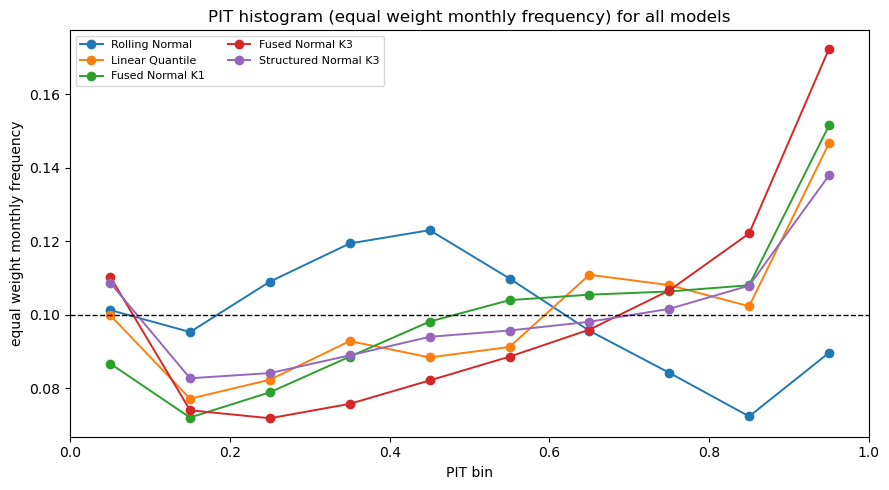

In [12]:
# ==========================================
# 10. 月份等权 PIT histogram
# ==========================================
fig, ax = plt.subplots(figsize=(9, 5))
bin_centers = (np.arange(10) + 0.5) / 10

for model_id in model_order:
    values = pit_histogram[pit_histogram["model_id"] == model_id].sort_values("pit_bin")
    ax.plot(bin_centers, values["frequency"], marker="o", linewidth=1.4, label=model_labels[model_id])

ax.axhline(0.10, color="black", linestyle="--", linewidth=1)
ax.set(title="PIT histogram (equal weight monthly frequency) for all models", xlabel="PIT bin", ylabel="equal weight monthly frequency", xlim=(0.0, 1.0)) 
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(figure_dir / f"pit_histogram.pdf", bbox_inches="tight", dpi=300)
plt.show()
# print("title: PIT histogram (equal weight monthly frequency) for all models")

In [13]:
# ==========================================
# 11. VaR coverage 诊断
# ==========================================
coverage_rows = []
for model_id in model_order:
    model_monthly = monthly_scores[monthly_scores["model_id"] == model_id]
    for alpha in alphas:
        suffix = alpha_suffix[alpha]
        coverage_error = model_monthly[f"coverage_{suffix}"].to_numpy() - alpha
        mean_error, nw_se, nw_t, p_value, n_months = newey_west_mean_test(coverage_error, newey_west_lags)
        coverage_rows.append({
            "model_id": model_id, "alpha": alpha, "coverage_rate": mean_error + alpha,
            "coverage_error": mean_error, "nw_se": nw_se, "nw_t": nw_t,
            "p_two_sided": p_value, "months": n_months,
        })
coverage_tests = pd.DataFrame(coverage_rows)
coverage_tests['significant_5pct'] = coverage_tests['p_two_sided'] < 0.05
coverage_tests.to_parquet(result_dir / f"coverage_tests_{timestamp}.parquet", index=False)

print("VaR coverage：coverage_rate 应接近 alpha；Newey-West 检验 H0: coverage_error = 0。significant_5pct = True 表示拒绝 H0，coverage_rate 与 alpha 有显著差异。")
display(coverage_tests.round(6))
display(coverage_tests[['model_id', 'alpha', 'coverage_rate', 'coverage_error', 'significant_5pct']].sort_values(by=["alpha"]).round(6))

VaR coverage：coverage_rate 应接近 alpha；Newey-West 检验 H0: coverage_error = 0。significant_5pct = True 表示拒绝 H0，coverage_rate 与 alpha 有显著差异。


,model_id,alpha,coverage_rate,coverage_error,nw_se,nw_t,p_two_sided,months,significant_5pct
0,rolling_normal,0.05,0.058581,0.008581,0.008486,1.011176,0.311932,216,False
1,rolling_normal,0.10,0.101303,0.001303,0.010978,0.118654,0.905550,216,False
2,linear_quantile,0.05,0.057230,0.007230,0.013379,0.540354,0.588953,216,False
3,linear_quantile,0.10,0.099905,-0.000095,0.019356,-0.004924,0.996072,216,False
4,fused_normal_k1,0.05,0.051760,0.001760,0.009814,0.179334,0.857676,216,False
5,fused_normal_k1,0.10,0.086749,-0.013251,0.014272,-0.928439,0.353180,216,False
6,fused_normal_k3,0.05,0.066574,0.016574,0.013954,1.187763,0.234927,216,False
7,fused_normal_k3,0.10,0.110358,0.010358,0.019628,0.527684,0.597718,216,False
8,structured_normal_k3,0.05,0.063621,0.013621,0.010488,1.298782,0.194019,216,False
9,structured_normal_k3,0.10,0.108717,0.008717,0.015322,0.568942,0.569396,216,False


,model_id,alpha,coverage_rate,coverage_error,significant_5pct
0,rolling_normal,0.05,0.058581,0.008581,False
2,linear_quantile,0.05,0.057230,0.007230,False
4,fused_normal_k1,0.05,0.051760,0.001760,False
6,fused_normal_k3,0.05,0.066574,0.016574,False
8,structured_normal_k3,0.05,0.063621,0.013621,False
1,rolling_normal,0.10,0.101303,0.001303,False
3,linear_quantile,0.10,0.099905,-0.000095,False
5,fused_normal_k1,0.10,0.086749,-0.013251,False
7,fused_normal_k3,0.10,0.110358,0.010358,False
9,structured_normal_k3,0.10,0.108717,0.008717,False


In [15]:
# ==========================================
# 读取 Train+Validation 确定的 component 标签
# ==========================================
label_cols = ["adverse_component", "normal_component", "favorable_component"]
component_names = ["adverse", "normal", "favorable"]

structured_cols = key_cols + [
    "target_ret_final", "model_id", "window", *label_cols,
    "pi_vec", "mu_vec", "sigma_vec", "var_5", "es_5",
]
structured_raw = pd.read_parquet(model_files["structured_normal_k3"],columns=structured_cols,)
structured_raw["mthcaldt"] = pd.to_datetime(structured_raw["mthcaldt"])

structured_metrics = pd.read_parquet(forecast_dir / f"structured_metrics_{timestamp}.parquet",
    columns=["window", "test_period", "component_mean_mu", "component_order", *label_cols],
).sort_values("window")

# ===================sanity check: 检查 structured_forecasts 与 structured_metrics 的 component 标签是否一致
# 检查每个 Test 窗口只有一套标签, 意思是同一个window不会出现不同的 component 标签组合。
forecast_label_map = structured_raw[["window"] + label_cols].drop_duplicates().sort_values("window")
if forecast_label_map["window"].duplicated().any():
    raise ValueError("同一个窗口出现多套 component 标签。")

expected = structured_metrics[["window"] + label_cols].to_numpy(dtype=int)
observed = forecast_label_map[["window"] + label_cols].to_numpy(dtype=int)
if not np.array_equal(expected, observed):
    raise ValueError("forecasts 与 metrics 保存的 component 标签不一致。")
# ==========================================


# 展示 Train+Validation 中对齐后的平均 mu
trainval_mu = decode_matrix(structured_metrics["component_mean_mu"])
trainval_order = decode_matrix(structured_metrics["component_order"]).astype(int)
trainval_mu_aligned = np.take_along_axis(trainval_mu, trainval_order, axis=1)

component_label_table = structured_metrics[["window", "test_period"] + label_cols].copy()
for k, name in enumerate(component_names):
    component_label_table[f"trainval_mean_mu_{name}"] = trainval_mu_aligned[:, k]

component_label_table.to_parquet(result_dir / f"component_label_table_{timestamp}.parquet", index=False)
display(component_label_table.round(6))

,window,test_period,adverse_component,normal_component,favorable_component,trainval_mean_mu_adverse,trainval_mean_mu_normal,trainval_mean_mu_favorable
0,0,2007-01 to 2007-12,1,2,0,-0.097681,0.010917,0.155617
1,1,2008-01 to 2008-12,0,1,2,-0.105350,0.000988,0.128545
2,2,2009-01 to 2009-12,2,0,1,-0.104454,0.004186,0.122395
3,3,2010-01 to 2010-12,1,2,0,-0.118718,-0.000299,0.103277
4,4,2011-01 to 2011-12,0,1,2,-0.128681,0.002257,0.114423
5,5,2012-01 to 2012-12,2,0,1,-0.130741,0.006383,0.123063
6,6,2013-01 to 2013-12,2,1,0,-0.110384,0.002313,0.123495
7,7,2014-01 to 2014-12,2,0,1,-0.095254,0.007794,0.134262
8,8,2015-01 to 2015-12,0,1,2,-0.110095,0.006796,0.128450
9,9,2016-01 to 2016-12,0,2,1,-0.083989,0.027348,0.132830


In [16]:
# ==========================================
# 使用已保存标签对齐 Test components
# ==========================================
pi = decode_matrix(structured_raw["pi_vec"])
mu = decode_matrix(structured_raw["mu_vec"])
sigma = decode_matrix(structured_raw["sigma_vec"])
order = structured_raw[label_cols].to_numpy(dtype=int)

pi = np.take_along_axis(pi, order, axis=1)
mu = np.take_along_axis(mu, order, axis=1)
sigma = np.take_along_axis(sigma, order, axis=1)

# 5% ES 精确分解
alpha = 0.05
q = structured_raw["var_5"].to_numpy(dtype=float)
stored_es = structured_raw["es_5"].to_numpy(dtype=float)

z = (q[:, None] - mu) / sigma
component_cdf = norm.cdf(z)
component_pdf = norm.pdf(z)

tail_weight = pi * component_cdf / alpha
es_contribution = pi * (mu * component_cdf - sigma * component_pdf) / alpha
severity = np.divide(
    es_contribution,
    tail_weight,
    out=np.full_like(es_contribution, np.nan),
    where=tail_weight > 1e-12,
)

structured_components = structured_raw[
    key_cols + ["target_ret_final", "model_id", "window", "var_5", "es_5"]
].copy()

structured_components["effective_k"] = 1.0 / np.sum(pi ** 2, axis=1)
structured_components["max_pi"] = pi.max(axis=1)
structured_components["adverse_is_lowest_mu"] = (
    (mu[:, 0] <= mu[:, 1]) & (mu[:, 0] <= mu[:, 2])
)
structured_components["es_reconstructed_5"] = es_contribution.sum(axis=1)

for k, name in enumerate(component_names):
    structured_components[f"pi_{name}"] = pi[:, k]
    structured_components[f"mu_{name}"] = mu[:, k]
    structured_components[f"sigma_{name}"] = sigma[:, k]
    structured_components[f"tail_weight_{name}_5"] = tail_weight[:, k]
    structured_components[f"severity_{name}_5"] = severity[:, k]
    structured_components[f"es_contribution_{name}_5"] = es_contribution[:, k]

structured_components["separation_adverse_normal"] = (
    np.abs(mu[:, 0] - mu[:, 1]) /
    np.sqrt((sigma[:, 0] ** 2 + sigma[:, 1] ** 2) / 2)
)
structured_components["separation_normal_favorable"] = (
    np.abs(mu[:, 1] - mu[:, 2]) /
    np.sqrt((sigma[:, 1] ** 2 + sigma[:, 2] ** 2) / 2)
)
structured_components.attrs["es_convention"] = "return"
structured_components.to_parquet(result_dir / f"structured_components_{timestamp}.parquet", index=False)   
display(structured_components.round(6))


,permno,mthcaldt,target_ret_final,model_id,window,var_5,es_5,effective_k,max_pi,adverse_is_lowest_mu,es_reconstructed_5,pi_adverse,mu_adverse,sigma_adverse,tail_weight_adverse_5,severity_adverse_5,es_contribution_adverse_5,pi_normal,mu_normal,sigma_normal,tail_weight_normal_5,severity_normal_5,es_contribution_normal_5,pi_favorable,mu_favorable,sigma_favorable,tail_weight_favorable_5,severity_favorable_5,es_contribution_favorable_5,separation_adverse_normal,separation_normal_favorable
0,10001,2007-01-31,0.264774,structured_normal_k3,0,-0.126501,-0.169206,2.378455,0.528514,False,-0.169206,0.528514,0.002418,0.082986,0.635823,-0.162251,-0.103163,0.358145,-0.008407,0.059959,0.175081,-0.149088,-0.026102,0.113341,0.129864,0.185444,0.189096,-0.211221,-0.039941,0.149524,1.003325
1,10025,2007-01-31,-0.028094,structured_normal_k3,0,-0.269773,-0.332184,2.378455,0.528514,True,-0.332184,0.528514,-0.083419,0.136923,0.917017,-0.332797,-0.305181,0.358145,0.025016,0.116528,0.040878,-0.307075,-0.012553,0.113341,0.150870,0.201832,0.042105,-0.343201,-0.014450,0.852912,0.763699
2,10026,2007-01-31,-0.038517,structured_normal_k3,0,-0.136563,-0.170743,2.378455,0.528514,True,-0.170743,0.528514,-0.034472,0.074874,0.912849,-0.170997,-0.156094,0.358145,0.001913,0.054184,0.037957,-0.153786,-0.005837,0.113341,0.095101,0.114697,0.049194,-0.179112,-0.008811,0.556754,1.038915
3,10032,2007-01-31,-0.023810,structured_normal_k3,0,-0.464835,-0.553728,2.378455,0.528514,True,-0.553728,0.528514,-0.214299,0.190412,0.994956,-0.553892,-0.551098,0.358145,0.028570,0.144049,0.002200,-0.501670,-0.001104,0.113341,0.307497,0.255553,0.002844,-0.536784,-0.001527,1.438543,1.344660
4,10044,2007-01-31,0.021561,structured_normal_k3,0,-0.184691,-0.239590,2.378455,0.528514,True,-0.239590,0.528514,-0.023670,0.114855,0.850522,-0.236806,-0.201409,0.358145,0.013576,0.078694,0.042092,-0.209954,-0.008837,0.113341,0.172501,0.213775,0.107385,-0.273256,-0.029344,0.378325,0.986631
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480441,93372,2024-12-31,0.093948,structured_normal_k3,17,-0.190452,-0.247913,1.855908,0.686069,True,-0.247913,0.254055,-0.106269,0.085338,0.822894,-0.235497,-0.193789,0.686069,0.039676,0.079982,0.027524,-0.213807,-0.005885,0.059876,0.115652,0.265997,0.149583,-0.322493,-0.048239,1.764678,0.386833
480442,93397,2024-12-31,-0.057236,structured_normal_k3,17,-0.103953,-0.136429,1.855908,0.686069,True,-0.136429,0.254055,-0.048826,0.056106,0.827779,-0.133612,-0.110601,0.686069,0.031148,0.050349,0.050019,-0.119417,-0.005973,0.059876,0.052368,0.123090,0.122203,-0.162470,-0.019854,1.500293,0.225656
480443,93426,2024-12-31,-0.007243,structured_normal_k3,17,-0.167370,-0.216650,1.855908,0.686069,True,-0.216650,0.254055,-0.091503,0.078285,0.844697,-0.208966,-0.176513,0.686069,0.037067,0.071308,0.028435,-0.188247,-0.005353,0.059876,0.110944,0.222937,0.126868,-0.274178,-0.034784,1.717055,0.446368
480444,93434,2024-12-31,0.147685,structured_normal_k3,17,-0.365104,-0.463546,1.855908,0.686069,True,-0.463546,0.254055,-0.182499,0.159668,0.642177,-0.444571,-0.285493,0.686069,0.020507,0.177932,0.207335,-0.428253,-0.088792,0.059876,0.161162,0.458772,0.150487,-0.593145,-0.089261,1.200890,0.404243


In [17]:
# ==========================================
# 月度和窗口层 component diagnostics
# ==========================================
monthly_agg = {
    "n_firms": ("permno", "size"),
    "effective_k": ("effective_k", "first"),
    "max_pi": ("max_pi", "first"),
    "adverse_lowest_firm_share": ("adverse_is_lowest_mu", "mean"),
    "mean_es_5": ("es_5", "mean"),
    "next_market_return_ew": ("target_ret_final", "mean"),
    "mean_separation_adverse_normal": ("separation_adverse_normal", "mean"),
    "mean_separation_normal_favorable": ("separation_normal_favorable", "mean"),
}

for name in component_names:
    monthly_agg[f"pi_{name}"] = (f"pi_{name}", "first")
    monthly_agg[f"mean_mu_{name}"] = (f"mu_{name}", "mean")
    monthly_agg[f"mean_sigma_{name}"] = (f"sigma_{name}", "mean")
    monthly_agg[f"mean_contribution_{name}"] = (f"es_contribution_{name}_5", "mean")

monthly_components = (
    structured_components.groupby(["window", "mthcaldt"], as_index=False)
    .agg(**monthly_agg)
)

monthly_components["adverse_mean_is_lowest"] = (
    (monthly_components["mean_mu_adverse"] <= monthly_components["mean_mu_normal"]) &
    (monthly_components["mean_mu_adverse"] <= monthly_components["mean_mu_favorable"])
)
monthly_components.to_parquet(result_dir / f"monthly_components_{timestamp}.parquet", index=False)
display(monthly_components.round(6))

,window,mthcaldt,n_firms,effective_k,max_pi,adverse_lowest_firm_share,mean_es_5,next_market_return_ew,mean_separation_adverse_normal,mean_separation_normal_favorable,pi_adverse,mean_mu_adverse,mean_sigma_adverse,mean_contribution_adverse,pi_normal,mean_mu_normal,mean_sigma_normal,mean_contribution_normal,pi_favorable,mean_mu_favorable,mean_sigma_favorable,mean_contribution_favorable,adverse_mean_is_lowest
0,0,2007-01-31,2870,2.378455,0.528514,0.993380,-0.318677,0.004801,0.934491,0.870580,0.528514,-0.095377,0.121283,-0.291179,0.358145,0.010873,0.090733,-0.004446,0.113341,0.151549,0.209692,-0.023052,True
1,0,2007-02-28,2871,1.678246,0.751535,0.994427,-0.338517,0.011785,0.934772,0.867843,0.751535,-0.096035,0.121647,-0.314262,0.114526,0.010853,0.091141,-0.000797,0.133939,0.151855,0.210684,-0.023457,True
2,0,2007-03-31,2854,1.755030,0.730182,0.994394,-0.337970,0.031077,0.941278,0.870040,0.730182,-0.096796,0.121965,-0.314980,0.145494,0.010932,0.091205,-0.001052,0.124324,0.152558,0.210705,-0.021938,True
3,0,2007-04-30,2864,1.996325,0.657566,0.993715,-0.330595,0.036165,0.933454,0.869067,0.657566,-0.095794,0.121856,-0.309361,0.241562,0.011004,0.091141,-0.002167,0.100872,0.152287,0.211078,-0.019067,True
4,0,2007-05-31,2863,1.999250,0.664239,0.994411,-0.331263,-0.003352,0.933918,0.865586,0.664239,-0.095119,0.121602,-0.305409,0.203978,0.011070,0.090864,-0.001692,0.131783,0.151103,0.210152,-0.024162,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,17,2024-08-31,2059,2.204294,0.510838,1.000000,-0.273580,0.011654,1.566369,0.319200,0.510838,-0.099418,0.089169,-0.226043,0.435715,0.037375,0.089443,-0.006075,0.053446,0.104714,0.266342,-0.041461,True
212,17,2024-09-30,2052,2.228896,0.473876,1.000000,-0.271527,-0.010163,1.567464,0.319656,0.470053,-0.099478,0.089159,-0.220336,0.473876,0.037425,0.089388,-0.007137,0.056071,0.104831,0.266412,-0.044054,True
213,17,2024-10-31,2076,2.093104,0.595049,1.000000,-0.262144,0.085400,1.569674,0.320040,0.346842,-0.099700,0.089291,-0.201784,0.595049,0.037418,0.089527,-0.012392,0.058109,0.105051,0.266680,-0.047968,True
214,17,2024-11-30,2088,2.208114,0.477088,1.000000,-0.270740,-0.064352,1.566338,0.320873,0.477088,-0.099597,0.089227,-0.223603,0.471865,0.037286,0.089477,-0.007135,0.051047,0.104944,0.266325,-0.040001,True


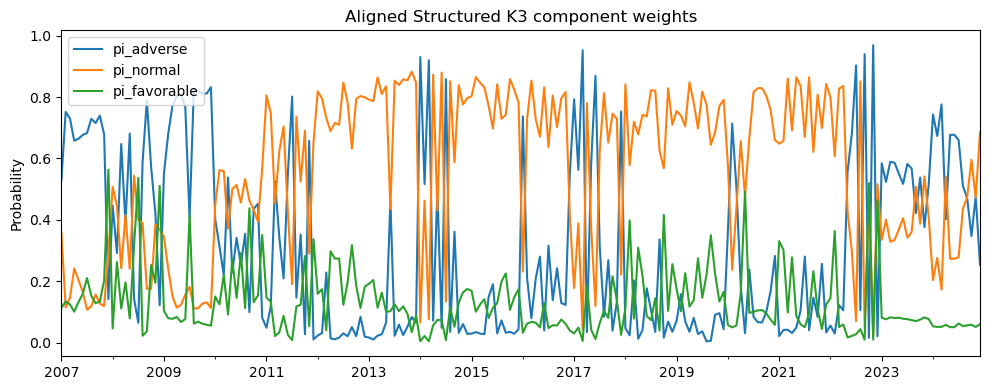

In [18]:
state_monthly = monthly_components[
    ["mthcaldt", "window", "pi_adverse", "pi_normal", "pi_favorable",
     "mean_es_5", "mean_contribution_adverse", "next_market_return_ew"]
].copy()
state_monthly["next_market_loss_ew"] = -state_monthly["next_market_return_ew"]
state_monthly.to_parquet(result_dir / f"state_monthly_{timestamp}.parquet", index=False)
ax = state_monthly.set_index("mthcaldt")[["pi_adverse", "pi_normal", "pi_favorable"]].plot(figsize=(10, 4))
ax.set(title="Aligned Structured K3 component weights", xlabel="", ylabel="Probability")
plt.tight_layout()
plt.savefig(figure_dir / f"components_weights.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [19]:
# 这个我觉得没必要保存
window_components = monthly_components.groupby("window", as_index=False).agg(
    test_start=("mthcaldt", "min"),
    test_end=("mthcaldt", "max"),
    months=("mthcaldt", "nunique"),
    mean_effective_k=("effective_k", "mean"),
    collapse_month_share=("max_pi", lambda x: (x > 0.95).mean()),
    adverse_lowest_firm_share=("adverse_lowest_firm_share", "mean"),
    adverse_lowest_month_share=("adverse_mean_is_lowest", "mean"),
    mean_pi_adverse=("pi_adverse", "mean"),
    mean_pi_normal=("pi_normal", "mean"),
    mean_pi_favorable=("pi_favorable", "mean"),
    mean_separation_adverse_normal=("mean_separation_adverse_normal", "mean"),
    mean_separation_normal_favorable=("mean_separation_normal_favorable", "mean"),
    mean_contribution_adverse=("mean_contribution_adverse", "mean"),
    mean_total_es=("mean_es_5", "mean"),
)
# window_components.to_parquet(result_dir / f"window_components_{timestamp}.parquet", index=False)
display(window_components.round(6))

,window,test_start,test_end,months,mean_effective_k,collapse_month_share,adverse_lowest_firm_share,adverse_lowest_month_share,mean_pi_adverse,mean_pi_normal,mean_pi_favorable,mean_separation_adverse_normal,mean_separation_normal_favorable,mean_contribution_adverse,mean_total_es
0,0,2007-01-31,2007-12-31,12,1.939435,0.000000,0.994715,1.0,0.641221,0.179254,0.179524,0.940089,0.869219,-0.292825,-0.331216
1,1,2008-01-31,2008-12-31,12,2.287385,0.000000,0.990249,1.0,0.429426,0.357143,0.213431,1.032118,1.099377,-0.264151,-0.294444
2,2,2009-01-31,2009-12-31,12,1.697424,0.000000,0.997633,1.0,0.740581,0.158831,0.100588,1.045425,1.033873,-0.323571,-0.327020
3,3,2010-01-31,2010-12-31,12,2.479161,0.000000,0.999369,1.0,0.309899,0.483418,0.206683,1.204738,0.940120,-0.266613,-0.297306
4,4,2011-01-31,2011-12-31,12,1.859414,0.000000,1.000000,1.0,0.315508,0.570473,0.114019,1.340721,0.983928,-0.244904,-0.287145
5,5,2012-01-31,2012-12-31,12,1.603108,0.000000,1.000000,1.0,0.045688,0.759601,0.194711,1.320070,0.937494,-0.081518,-0.205425
6,6,2013-01-31,2013-12-31,12,1.473474,0.000000,0.999221,1.0,0.075775,0.804705,0.119520,1.124235,1.017920,-0.086862,-0.204098
7,7,2014-01-31,2014-12-31,12,1.542949,0.000000,1.000000,1.0,0.363050,0.564090,0.072860,1.083070,1.143371,-0.180381,-0.240848
8,8,2015-01-31,2015-12-31,12,1.511068,0.000000,1.000000,1.0,0.058376,0.799198,0.142426,1.179274,1.077587,-0.090258,-0.196739
9,9,2016-01-31,2016-12-31,12,1.678484,0.000000,1.000000,1.0,0.254097,0.684291,0.061611,1.349318,0.846439,-0.163604,-0.207401


In [20]:
# 总体的一个检查表
pi_cols = ["pi_adverse", "pi_normal", "pi_favorable"]
pi_spread = (
    structured_components.groupby("mthcaldt")[pi_cols].max() -
    structured_components.groupby("mthcaldt")[pi_cols].min()
)

component_checks = pd.Series({
    "max_ES_reconstruction_error": np.max(
        np.abs(structured_components["es_reconstructed_5"] - stored_es)
    ),
    "max_tail_weight_sum_error": np.max(np.abs(tail_weight.sum(axis=1) - 1.0)),
    "max_within_month_pi_spread": pi_spread.to_numpy().max(),
    "mean_effective_k": monthly_components["effective_k"].mean(),
    "collapse_month_share": (monthly_components["max_pi"] > 0.95).mean(),
    "adverse_lowest_month_share": monthly_components["adverse_mean_is_lowest"].mean(),
    "adverse_lowest_firm_share": monthly_components["adverse_lowest_firm_share"].mean(),
    "adverse_ES_contribution_ratio": (
        monthly_components["mean_contribution_adverse"].mean() /
        monthly_components["mean_es_5"].mean()
    ),
})

component_check_table = component_checks.rename_axis("check").reset_index(name="value")
component_check_table.to_parquet(result_dir / f"component_check_table_{timestamp}.parquet", index=False) 
display(component_check_table.round(6))

,check,value
0,max_ES_reconstruction_error,0.000000
1,max_tail_weight_sum_error,0.000000
2,max_within_month_pi_spread,0.000000
3,mean_effective_k,1.796170
4,collapse_month_share,0.009259
5,adverse_lowest_month_share,1.000000
6,adverse_lowest_firm_share,0.996927
7,adverse_ES_contribution_ratio,0.737834
